In [1]:
import networkx as nx 
from sym_graphs.utils.utils import yaml_to_dotdict, group_by_epsilon
from sym_graphs.correlators.k_correlators import Correlator
import matplotlib.pyplot as plt 
import itertools
from sym_graphs.k_orbits.orbits_calculator import OrbitEngine 
import math
import numpy as np 

In [2]:

def _oklch_to_oklab(L, C, h):
    a = math.cos(h) * C
    b = math.sin(h) * C
    return L, a, b

def _oklab_to_lin_srgb(L, a, b):
    l_ = L + 0.3963377774*a + 0.2158037573*b
    m_ = L - 0.1055613458*a - 0.0638541728*b
    s_ = L - 0.0894841775*a - 1.2914855480*b
    l, m, s = l_**3, m_**3, s_**3
    r =  4.0767416621*l - 3.3077115913*m + 0.2309699292*s
    g = -1.2684380046*l + 2.6097574011*m - 0.3413193965*s
    b = -0.0041960863*l - 0.7034186147*m + 1.7076147010*s
    return r, g, b

def _lin_to_srgb(u):
    return 12.92*u if u <= 0.0031308 else 1.055*(u**(1/2.4)) - 0.055

def _to_hex(r, g, b):
    clamp = lambda x: min(max(x, 0.0), 1.0)
    R = int(round(255 * clamp(_lin_to_srgb(r))))
    G = int(round(255 * clamp(_lin_to_srgb(g))))
    B = int(round(255 * clamp(_lin_to_srgb(b))))
    return f"#{R:02X}{G:02X}{B:02X}"

# --- Generator: k well-spaced hues, steadily darkening lightness ---
def oklch_palette(k, l_start=0.86, l_end=0.36, chroma=0.09, h0=0.08):
    """
    k: number of colors
    l_start -> l_end: lightness range (bright → dark)
    chroma: saturation (~0.07–0.12 keeps most colors in sRGB gamut)
    h0: starting hue in turns (0..1); tweak if you want a different first color
    """
    if k <= 0:
        return []
    phi = 0.6180339887498948  # golden ratio conjugate for even hue dispersion
    out = []
    for i in range(k):
        t  = 0 if k == 1 else i/(k-1)
        L  = (1 - t)*l_start + t*l_end
        h  = 2*math.pi * ((h0 + i*phi) % 1.0)
        L_, a_, b_ = _oklch_to_oklab(L, chroma, h)
        r, g, b = _oklab_to_lin_srgb(L_, a_, b_)
        out.append(_to_hex(r, g, b))
    return out



In [3]:
edge_list = [(7, 10), (10, 11), (5, 8), (5, 7), (5, 13), (7, 15),
 (0, 1), (0, 10), (0, 6), (0, 8), (0, 13), (1, 3),
 (1, 4), (1, 9), (1, 15), (2, 3), (2, 10), (2, 8),
 (2, 12), (2, 15), (3, 6), (3, 5), (3, 11), (4, 10),
 (4, 5), (4, 12), (4, 14), (6, 7), (6, 12), (6, 14),
 (8, 9), (8, 14), (7, 9), (9, 11), (9, 12), (11, 13),
 (11, 14), (12, 13), (13, 15), (14, 15)]
Clebsch = nx.Graph()
Clebsch.add_edges_from(edge_list)

# The generators are obtained from an online API of SageMath (could not install it here
# due to dependencies clashes) 
gens = [
    [(2,11),(8,13),(9,15),(12,14)],
    [(0,2),(1,12),(3,13),(6,15)],
    [(5,1),(7,0),(8,15),(9,13)],
    [(5,6),(0,4),(8,12),(13,14)],
    [(10,5),(0,3),(2,13),(8,11)],
]

## Compute the dynamics using emu-SV

In [10]:
cfg_file = "../configs/emu_cfg/config_large.yaml"
cfg = yaml_to_dotdict(cfg_file)
Corr = Correlator(Clebsch, cfg)
res_SV = Corr.emulate_non_UD("SV")

../../../../sym_graphs/lib/python3.11/site-packages/pulser/register/register.py:58: DeprecationWarning: Usage of `int`s or any non-`str`types as `QubitId`s will be deprecated. Define your `QubitId`s as `str`s, prefer setting `prefix='q'` when using classmethods, as that will become the new default once `int` qubit IDs become invalid.
  super().__init__(qubits, **kwargs)


step = 1/500, RSS = 887.292 MB, Δt = 0.023 s
step = 2/500, RSS = 887.292 MB, Δt = 0.022 s
step = 3/500, RSS = 887.292 MB, Δt = 0.027 s
step = 4/500, RSS = 887.292 MB, Δt = 0.029 s
step = 5/500, RSS = 887.292 MB, Δt = 0.028 s
step = 6/500, RSS = 889.184 MB, Δt = 0.033 s
step = 7/500, RSS = 889.972 MB, Δt = 0.033 s
step = 8/500, RSS = 892.080 MB, Δt = 0.042 s
step = 9/500, RSS = 892.080 MB, Δt = 0.041 s
step = 10/500, RSS = 894.192 MB, Δt = 0.045 s
step = 11/500, RSS = 894.192 MB, Δt = 0.041 s
step = 12/500, RSS = 894.192 MB, Δt = 0.041 s
step = 13/500, RSS = 895.248 MB, Δt = 0.045 s
step = 14/500, RSS = 904.516 MB, Δt = 0.049 s
step = 15/500, RSS = 906.476 MB, Δt = 0.046 s
step = 16/500, RSS = 907.532 MB, Δt = 0.046 s
step = 17/500, RSS = 908.588 MB, Δt = 0.047 s
step = 18/500, RSS = 909.640 MB, Δt = 0.047 s
step = 19/500, RSS = 910.696 MB, Δt = 0.047 s
step = 20/500, RSS = 911.812 MB, Δt = 0.054 s
step = 21/500, RSS = 912.768 MB, Δt = 0.047 s
step = 22/500, RSS = 915.896 MB, Δt = 0.052

# chose an order for the symmetries :

In [11]:
k = 3

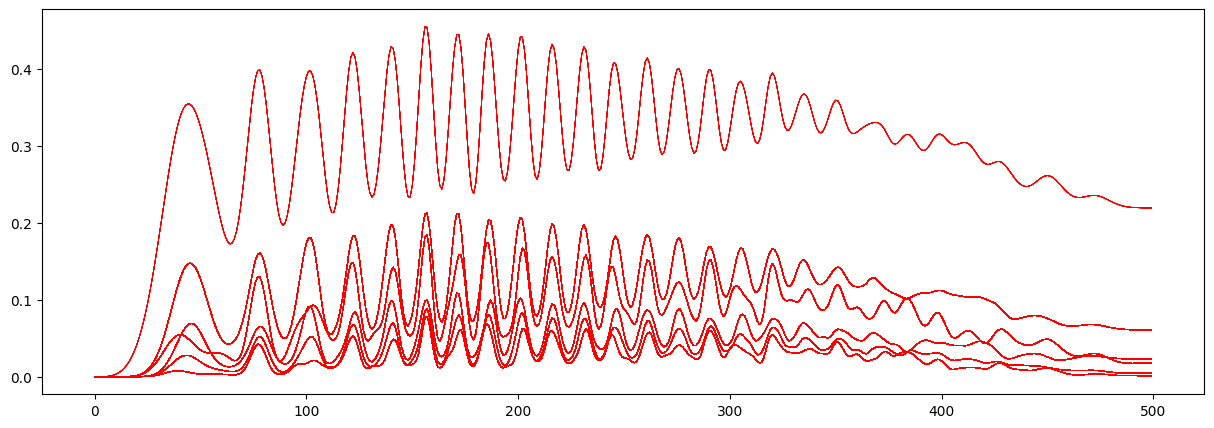

In [12]:
C = Corr.k_body_full_chunked(res_SV,k, chunk_s = 496, chunk_t = 128)
Basis =  list(itertools.product(range(len(Clebsch)), repeat= k ))
plt.figure(figsize=(15,5))
for elem in Basis : 
    plt.plot(C[:,*elem].cpu(),"r",lw = .5)

In [13]:
eps = 1e-5
groups = group_by_epsilon(np.array(C.cpu().mean(0)), eps)

/tmp/ipykernel_1380627/2275479000.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  groups = group_by_epsilon(np.array(C.cpu().mean(0)), eps)


# Now the ground-truth Orbit calculator 

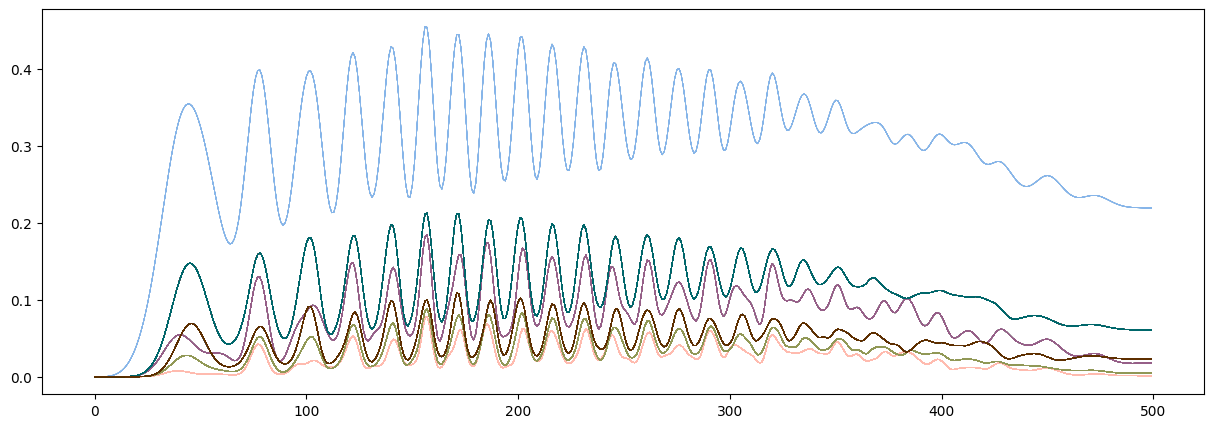

In [ ]:
OC = OrbitEngine(Clebsch, gens)
orbits = OC.orbits_calculator(k)
colors = oklch_palette(len(orbits))
plt.figure(figsize=(15,5))
for u,O in enumerate(orbits):
    for e in O :
        plt.plot(C.cpu()[:,*e],c = colors[u],lw = .5)
